In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from datetime import datetime

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
hplanck = 6.62607015e-27   # erg*s
clight = 2.99792458e10     # cm/s
pi = np.pi

In [7]:
# Set the relevant input information: 
# Source: AB magnitude
m = 24.0
# Exposure time: in seconds
texp = 3600.0
# Number of exposures that this exposure time is split into
nexp = 3

In [8]:
# ------------------------------------------------------------
# Spec-S5 throughput (point source, 0.96 arcsec seeing)
lam_t = np.array([360.,375,400.,450.,500.,550.,600.,650.,700.,750.,800.,850.,900.,980.]) * 10.0  # Å
# Fiber diameter = 120 micron
# thru_s5 = np.array([0.0422,0.0596,0.0837,0.1269,0.1231,0.1147,0.1322,0.1414,0.14,0.1288,0.1548,0.156,0.1569,0.1012])
# thru_s5_sky = np.array([0.0959,0.1343,0.1871,0.2813,0.2716,0.2529,0.2920,0.3133,0.3109,0.2865,0.3444,0.3471,0.3497,0.2261])
# df_s5 = 1.144  # arcsec fiber diameter
# Fiber diameter = 107 micron (baseline)
thru_s5 = [0.0373, 0.0526, 0.0740, 0.1122, 0.1089, 0.1015, 0.1169, 0.125, 0.1237, 0.1138, 0.1368, 0.1378, 0.1387, 0.0895]
thru_s5_sky = [0.0959, 0.1343, 0.1871, 0.2813, 0.2716, 0.2529, 0.2920, 0.3133, 0.3109, 0.2865, 0.3444, 0.3471, 0.3497, 0.2261]
df_s5 = 1.02 # fiber diameter

# ------------------------------------------------------------
# DESI throughput
thru_d = np.array([0.0253,0.0409,0.0623,0.0863,0.0940,0.0933,0.1117,0.1216,0.1231,0.1155,0.1433,0.1456,0.1440,0.0845])
thru_d_sky = np.array([0.0631,0.1017,0.1537,0.2113,0.2284,0.2262,0.2716,0.2976,0.3033,0.2859,0.3558,0.3619,0.3586,0.2107])
df_d = 1.51  # arcsec fiber diameter

# ------------------------------------------------------------
# Higher resolution wavelength grid
lam = np.linspace(lam_t.min(), lam_t.max(), 1001)

# ------------------------------------------------------------
# Sky spectrum (in erg/s/cm^2/Å/arcsec^2)
flamsky = np.array([1.69E-17,1.50E-17,1.22E-17,1.59E-17,1.03E-17,1.02E-17,
                    9.59E-18,7.89E-18,8.02E-18,7.73E-18,7.76E-18,7.73E-18,5.86E-18,8.00E-18])
phsky = flamsky / (hplanck * clight * 1e8 / lam_t)   # photons/s/cm^2/Å/arcsec^2

# ------------------------------------------------------------
# Source: convert AB magnitude into flux density fnu
fnu = 10**(-0.4*(48.6 + m)) * np.ones_like(lam_t)

# Convert fν to fλ (erg/s/cm^2/Å)
# fλ = fν * c / λ^2
flam = fnu * (clight * 1e8) / (lam_t**2)

# Convert to photons per cm^2 per sec per Å
phot = flam / (hplanck * clight * 1e8 / lam_t)

# ------------------------------------------------------------
# Noise terms
noise_ccd_d = np.array([3.35]*6 + [2.72]*8)
noise_ccd_s5 = np.array([1.18]*6 + [2.72]*8)

# Telescope diameters (cm)
d_d = 3.797e2
d_s5 = 6.0e2

# ------------------------------------------------------------
# DESI
ph_d = phot * pi * (d_d/2)**2 * texp * thru_d
phsky_d = phsky * pi * (d_d/2)**2 * texp * pi * (df_d/2)**2 * thru_d_sky
noise_d = np.sqrt(phsky_d + nexp * noise_ccd_d**2)
snr_d = ph_d / noise_d

# ------------------------------------------------------------
# Spec-S5
ph_s5 = phot * pi * (d_s5/2)**2 * texp * thru_s5
phsky_s5 = phsky * pi * (d_s5/2)**2 * texp * pi * (df_s5/2)**2 * thru_s5_sky
noise_s5 = np.sqrt(phsky_s5 + nexp * noise_ccd_s5**2)
snr_s5 = ph_s5 / noise_s5

# ------------------------------------------------------------
# Interpolate to high-res wavelength grid
interp_ph_d = interp1d(lam_t, ph_d, kind='cubic')
interp_ph_s5 = interp1d(lam_t, ph_s5, kind='cubic')
interp_snr_d = interp1d(lam_t, snr_d, kind='cubic')
interp_snr_s5 = interp1d(lam_t, snr_s5, kind='cubic')

ph_d_lam = interp_ph_d(lam)
ph_s5_lam = interp_ph_s5(lam)
snr_d_lam = interp_snr_d(lam)
snr_s5_lam = interp_snr_s5(lam)

area_ratio = (d_s5/d_d)**2 * ph_d
area_ratio_lam = interp1d(lam_t, area_ratio, kind='cubic')(lam)

# Calculate the mean z-arm (DESI) SNR
i = (lam_t > 7470.) & (lam_t < 9800.)
VRAD_ERR = 10.0**(1.389 - 0.975*np.log10(np.median(snr_s5[i])))

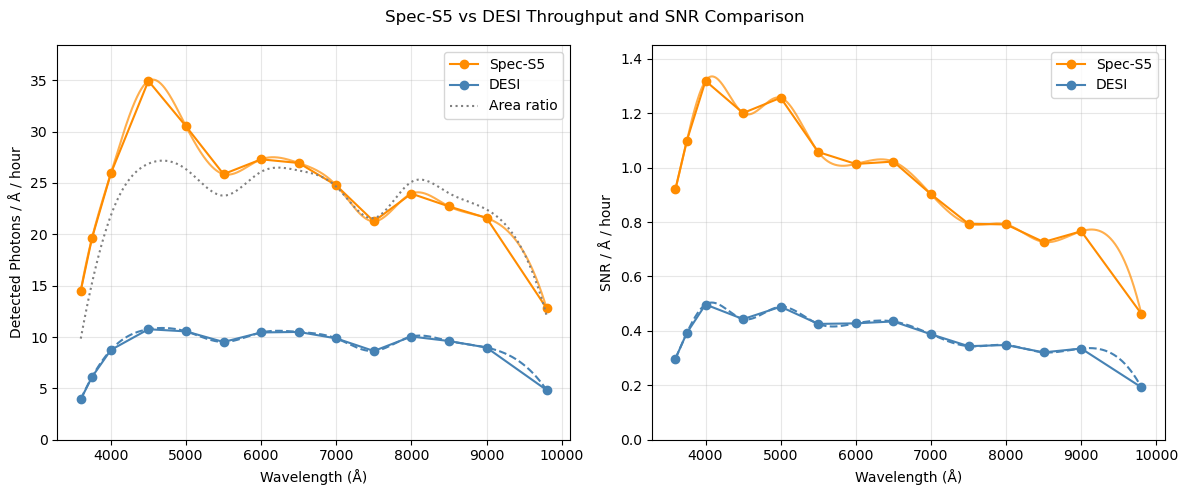

In [14]:
# ------------------------------------------------------------
# Plot results
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: photon rate
axs[0].plot(lam_t, ph_s5, 'o-', label='Spec-S5', color='darkorange')
axs[0].plot(lam, ph_s5_lam, '-', color='darkorange', alpha=0.7)
axs[0].plot(lam_t, ph_d, 'o-', label='DESI', color='steelblue')
axs[0].plot(lam, ph_d_lam, '--', color='steelblue')
axs[0].plot(lam, area_ratio_lam, ':', color='gray', label='Area ratio')
axs[0].set(xlabel='Wavelength (Å)', ylabel='Detected Photons / Å / hour',
           ylim=[0,np.max(ph_s5)*1.1])
axs[0].legend()
axs[0].grid(alpha=0.3)

# Panel 2: SNR
axs[1].plot(lam_t, snr_s5, 'o-', label='Spec-S5', color='darkorange')
axs[1].plot(lam, snr_s5_lam, '-', color='darkorange', alpha=0.7)
axs[1].plot(lam_t, snr_d, 'o-', label='DESI', color='steelblue')
axs[1].plot(lam, snr_d_lam, '--', color='steelblue')
axs[1].set(xlabel='Wavelength (Å)', ylabel='SNR / Å / hour', ylim=[0,np.max(snr_s5)*1.1])
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.suptitle('Spec-S5 vs DESI Throughput and SNR Comparison')
plt.tight_layout()
plt.savefig('SpecS5_vs_DESI_throughput_new.png')
plt.show()

In [119]:

# ------------------------------------------------------------
# Optional: print summary
print(f'Magnitude = {m} AB mag; Exptime = {texp} sec split into {nexp} exposures')
print(f'Mean VRAD error = {VRAD_ERR:6.2f} km/s')
print(f'Wavelength(A)  Photons/A  SNR/A')
for lt, ph, snr in zip(lam_t, ph_s5, snr_s5):
    print(f"{lt:7.0f} Å  {ph:10.3e}  {snr:7.3f}")


Magnitude = 22.0 AB mag; Exptime = 3600.0 sec split into 3 exposures
Mean VRAD error =   5.19 km/s
Wavelength(A)  Photons/A  SNR/A
   3600 Å   9.159e+01    5.810
   3750 Å   1.240e+02    6.926
   4000 Å   1.635e+02    8.319
   4500 Å   2.204e+02    7.574
   5000 Å   1.925e+02    7.927
   5500 Å   1.631e+02    6.670
   6000 Å   1.722e+02    6.393
   6500 Å   1.700e+02    6.448
   7000 Å   1.562e+02    5.693
   7500 Å   1.341e+02    5.007
   8000 Å   1.512e+02    4.991
   8500 Å   1.433e+02    4.585
   9000 Å   1.362e+02    4.833
   9800 Å   8.073e+01    2.920


In [128]:
def compute_snr(m, nexp, texp, fiber_diameter=107):
    """
    Compute photon counts and SNR for DESI and Spec-S5 instruments
    given an input AB magnitude, number of exposures, and total exposure time.
    
    Parameters
    ----------
    m : float
        Source AB magnitude
    nexp : int
        Number of exposures
    texp : float
        Effective exposure time per exposure (seconds)
    fiber_diameter : needs to be either 107 or 120 (in microns)
    
    Returns
    -------
    dict
        Dictionary containing wavelength array, photon counts, SNR arrays and VRAD_ERR for both systems .
    """
    
    # --- Physical constants ---
    hplanck = 6.62607015e-27   # erg*s
    clight = 2.99792458e10     # cm/s

    # --- Throughput data ---
    lam_t = np.array([360.,375,400.,450.,500.,550.,600.,650.,700.,750.,800.,850.,900.,980.]) * 10.0  # Å

    if fiber_diameter == 107: # ... for Spec-S5 (107 micron fiber and 0.96 arcsec seeing)
        thru_s5 = np.array([0.0373, 0.0526, 0.0740, 0.1122, 0.1089, 0.1015, 0.1169, 
                            0.125, 0.1237, 0.1138, 0.1368, 0.1378, 0.1387, 0.0895])
        thru_s5_sky = np.array([0.0959, 0.1343, 0.1871, 0.2813, 0.2716, 0.2529, 0.2920, 
                                0.3133, 0.3109, 0.2865, 0.3444, 0.3471, 0.3497, 0.2261])
        df_s5 = 1.02  # arcsec fiber diameter (approximate)
    elif fiber_diameter == 120:
        thru_s5 = np.array([0.0422,0.0596, 0.0837,  0.1269, 0.1231, 0.1147, 0.1322, 
                            0.1414, 0.14,   0.1288, 0.1548, 0.156,  0.1569, 0.1012])
        thru_s5_sky = np.array([0.0959, 0.1343, 0.1871, 0.2813, 0.2716, 0.2529, 0.2920, 
                                0.3133, 0.3109, 0.2865, 0.3444, 0.3471, 0.3497, 0.2261])
        df_s5 = 1.144  # arcsec fiber diameter
    else:
        raise ValueError("fiber_diameter must be either the baseline of 107 microns or the larger dia of 120 microns.")


    # ... for DESI (107 micron fiber and 0.96 arcsec seeing) - baseline design
    thru_d = np.array([0.0253,0.0409,0.0623,0.0863,0.0940,0.0933,0.1117,0.1216,0.1231,0.1155,0.1433,0.1456,0.1440,0.0845])
    thru_d_sky = np.array([0.0631,0.1017,0.1537,0.2113,0.2284,0.2262,0.2716,0.2976,0.3033,0.2859,0.3558,0.3619,0.3586,0.2107])
    df_d = 1.51  # arcsec fiber diameter for 107 micron diameter fibers

    # --- Telescope diameters (cm) ---
    d_d = 3.797e2
    d_s5 = 6.0e2

    # --- Sky spectrum (erg/s/cm^2/Å/arcsec^2) ---
    flamsky = np.array([1.69E-17,1.50E-17,1.22E-17,1.59E-17,1.03E-17,1.02E-17,
                        9.59E-18,7.89E-18,8.02E-18,7.73E-18,7.76E-18,7.73E-18,5.86E-18,8.00E-18])
    phsky = flamsky / (hplanck * clight * 1e8 / lam_t)   # photons/s/cm^2/Å/arcsec^2

    # --- Convert AB magnitude to photon flux ---
    fnu = 10**(-0.4*(m + 48.6)) * np.ones_like(lam_t)
    flam = fnu * (clight * 1e8) / (lam_t**2)
    phot = flam / (hplanck * clight * 1e8 / lam_t)

    # --- Noise terms ---
    noise_ccd_d = np.array([3.35]*6 + [2.72]*8)
    noise_ccd_s5 = np.array([1.18]*6 + [2.72]*8)

    # --- DESI ---
    ph_d = phot * pi * (d_d/2)**2 * texp * thru_d
    phsky_d = phsky * pi * (d_d/2)**2 * texp * pi * (df_d/2)**2 * thru_d_sky
    noise_d = np.sqrt(phsky_d + nexp * noise_ccd_d**2)
    snr_d = ph_d / noise_d

    # --- Spec-S5 ---
    ph_s5 = phot * pi * (d_s5/2)**2 * texp * thru_s5
    phsky_s5 = phsky * pi * (d_s5/2)**2 * texp * pi * (df_s5/2)**2 * thru_s5_sky
    noise_s5 = np.sqrt(phsky_s5 + nexp * noise_ccd_s5**2)
    snr_s5 = ph_s5 / noise_s5

    # --- Interpolate to fine wavelength grid ---
    lam = np.linspace(lam_t.min(), lam_t.max(), 1001)
    interp_snr_d = interp1d(lam_t, snr_d, kind='cubic')
    interp_snr_s5 = interp1d(lam_t, snr_s5, kind='cubic')
    interp_ph_d = interp1d(lam_t, ph_d, kind='cubic')
    interp_ph_s5 = interp1d(lam_t, ph_s5, kind='cubic')

    snr_d_lam = interp_snr_d(lam)
    snr_s5_lam = interp_snr_s5(lam)
    ph_d_lam = interp_ph_d(lam)
    ph_s5_lam = interp_ph_s5(lam)

    # --- Velocity error example (S5 red arm) ---
    i = (lam_t > 7470.) & (lam_t < 9800.)
    VRAD_ERR = 10.0**(1.389 - 0.975*np.log10(np.median(snr_s5[i])) - 0.975*np.log10(0.8)) 
        # last term to convert from per DESI pixel to per Angstrom

    return {
        "lam": lam,
        "snr_d_lam": snr_d_lam,
        "snr_s5_lam": snr_s5_lam,
        "ph_d_lam": ph_d_lam,
        "ph_s5_lam": ph_s5_lam,
        "lam_t": lam_t,
        "snr_d_t": snr_d,
        "snr_s5_t": snr_s5,
        "ph_d_t": ph_d,
        "ph_s5_t": ph_s5,
        "VRAD_ERR": VRAD_ERR,
        "fiber_diameter": fiber_diameter,
        "abmag":m,
        "exptime":texp,
        "nexp":nexp
    }

In [129]:
def plot_snr_comparison(result_dict):
    """
    Plot photon rate and SNR comparison for Spec-S5 vs DESI.

    Parameters
    ----------
    result_dict : dict
        Output dictionary from compute_snr(), expected to include:
        lam, lam_t, ph_s5, ph_s5_lam, ph_d, ph_d_lam,
        snr_s5, snr_s5_lam, snr_d, snr_d_lam,
        area_ratio_lam (optional)
    """

    # Extract relevant quantities
    lam_t = result_dict.get("lam_t", None)
    ph_s5_t = result_dict.get("ph_s5_t", None)
    ph_d_t = result_dict.get("ph_d_t", None)
    snr_s5_t = result_dict.get("snr_s5_t", None)
    snr_d_t = result_dict.get("snr_d_t", None)
    lam = result_dict["lam"]
    ph_s5_lam = result_dict["ph_s5_lam"]
    ph_d_lam = result_dict["ph_d_lam"]
    snr_s5_lam = result_dict["snr_s5_lam"]
    snr_d_lam = result_dict["snr_d_lam"]
    fiber_diameter = result_dict.get("fiber_diameter", None)
    exptime = result_dict.get("exptime",None)

    # Create figure
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: photon rate
    if lam_t is not None and ph_s5 is not None:
        axs[0].plot(lam_t, ph_s5_t, 'o-', label='Spec-S5', color='darkorange')
    axs[0].plot(lam, ph_s5_lam, '-', color='darkorange', alpha=0.7)
    if lam_t is not None and ph_d is not None:
        axs[0].plot(lam_t, ph_d_t, 'o-', label='DESI', color='steelblue')
    axs[0].plot(lam, ph_d_lam, '--', color='steelblue')
#    if area_ratio_lam is not None:
#        axs[0].plot(lam, area_ratio_lam, ':', color='gray', label='Area ratio')

    axs[0].set(
        xlabel='Wavelength (Å)',
        ylabel='Detected Photons / Å',
        ylim=[0, np.max(ph_s5_lam)*1.1]
    )
    axs[0].legend()
    axs[0].grid(alpha=0.3)

    # Panel 2: SNR
    if lam_t is not None and snr_s5 is not None:
        axs[1].plot(lam_t, snr_s5_t, 'o-', label='Spec-S5', color='darkorange')
    axs[1].plot(lam, snr_s5_lam, '-', color='darkorange', alpha=0.7)
    if lam_t is not None and snr_d is not None:
        axs[1].plot(lam_t, snr_d_t, 'o-', label='DESI', color='steelblue')
    axs[1].plot(lam, snr_d_lam, '--', color='steelblue')

    axs[1].set(
        xlabel='Wavelength (Å)',
        ylabel='SNR / Å',
        ylim=[0, np.max(snr_s5_lam)*1.1]
    )
    axs[1].legend()
    axs[1].grid(alpha=0.3)

    plt.suptitle(f'Spec-S5 vs DESI Throughput and SNR Comparison texp={result_dict["exptime"]}\n(Fiber = {result_dict["fiber_diameter"]} µm)')
    plt.tight_layout()
    plt.show()


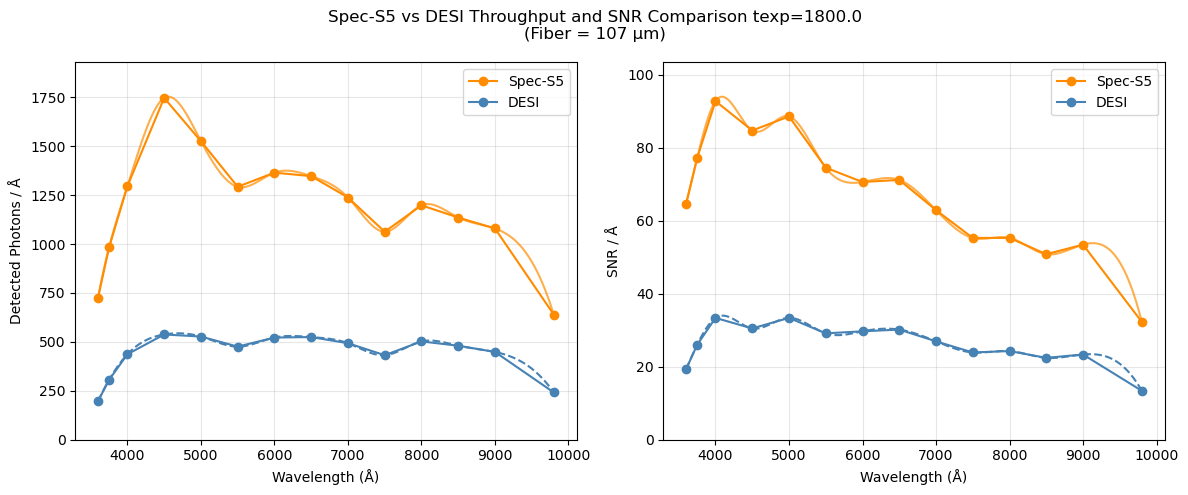

In [134]:
result = compute_snr(m=19.0, nexp=3, texp=1800.0, fiber_diameter=107)
plot_snr_comparison(result)

In [135]:
# Optional: print summary
print(f'Magnitude = {result["abmag"]} AB mag; Exptime = {result["exptime"]} sec split into {result["nexp"]} exposures')
print(f'Mean VRAD error = {result["VRAD_ERR"]:6.2f} km/s')
print(f'Wavelength(A)  Photons/A  SNR/A')
for lt, ph, snr in zip(result["lam_t"], result["ph_s5_t"], result["snr_s5_t"]):
    print(f"{lt:7.0f} Å  {ph:10.3e}  {snr:7.3f}")

Magnitude = 19.0 AB mag; Exptime = 1800.0 sec split into 3 exposures
Mean VRAD error =   0.62 km/s
Wavelength(A)  Photons/A  SNR/A
   3600 Å   7.258e+02   64.576
   3750 Å   9.826e+02   77.119
   4000 Å   1.296e+03   92.726
   4500 Å   1.747e+03   84.668
   5000 Å   1.526e+03   88.529
   5500 Å   1.293e+03   74.488
   6000 Å   1.365e+03   70.578
   6500 Å   1.347e+03   71.140
   7000 Å   1.238e+03   62.877
   7500 Å   1.063e+03   55.263
   8000 Å   1.198e+03   55.265
   8500 Å   1.136e+03   50.805
   9000 Å   1.080e+03   53.426
   9800 Å   6.397e+02   32.259


In [98]:
1.389 - 0.975*np.log10(0.8)

1.483487262682855